<a href="https://colab.research.google.com/github/harishmuh/Deep-Learning-with-Pytorch-tutorials/blob/main/13_training_notebook_Vegetable_images_classification_with_transfer_learning_Pytorch_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Vegetable image classification with transfer learning efficient net**

## **Context**

In this notebook, we will try to implement transfer learning to classify vegetable images with the help of transfer learning efficient net.

**About dataset**

The dataset is originated from this [paper](https://www.researchgate.net/publication/379243877_DCNN-BASED_VEGETABLE_IMAGE_CLASSIFICATION_USING_TRANSFER_LEARNING_A_COMPARATIVE_STUDY) published in 2021 in the ICCCSP conference by IEEE.

The initial experiment is done with 15 types of common vegetables that are found throughout the world that consist of bean, bitter gourd, bottle gourd, brinjal, broccoli, cabbage, capsicum, carrot, cauliflower, cucumber, papaya, potato, pumpkin, radish and tomato

This dataset contains three folders:
* train (15000 images)
* test (3000 images)
* validation (3000 images)

each of the above folders contains subfolders for different vegetables wherein the images for respective vegetables are present.

## **Initial setup**

In [ ]:
# Importing libraries
import torch
import random
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score
import os
import torch
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms
from PIL import Image
import scipy.io
import numpy as np
import requests
import zipfile
from pathlib import Path

# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

device

device(type='cuda')

## **Dataset Preparation**

**Downloading dataset**

The dataset has been made available by M. Israk Ahmed in Kaggle website. We will download the dataset from this website.

In [ ]:
# Connecting dataset
import kagglehub
misrakahmed_vegetable_image_dataset_path = kagglehub.dataset_download('misrakahmed/vegetable-image-dataset')

print('Data source import complete.')

Using Colab cache for faster access to the 'vegetable-image-dataset' dataset.
Data source import complete.


In [ ]:
# Location of the dataset
print(f"The vegetable-image-dataset is located at: {misrakahmed_vegetable_image_dataset_path}")

# We can list the contents of this directory to see the dataset structure
import os
os.listdir(misrakahmed_vegetable_image_dataset_path)

The vegetable-image-dataset is located at: /kaggle/input/vegetable-image-dataset


['Vegetable Images']

In [ ]:
# Check GPU
!nvidia-smi

Tue Jun  2 04:36:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

**Setting path**

In [ ]:
# Setup path to data folder

data_path = Path("data/")
# Update image_path to point to the actual downloaded Kaggle dataset folder
image_path = Path(misrakahmed_vegetable_image_dataset_path) / "Vegetable Images"

image_path

PosixPath('/kaggle/input/vegetable-image-dataset/Vegetable Images')

In [ ]:
# Setup train and testing paths
train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir, test_dir

(PosixPath('/kaggle/input/vegetable-image-dataset/Vegetable Images/train'),
 PosixPath('/kaggle/input/vegetable-image-dataset/Vegetable Images/test'))

**Setting data preprocessing**

In [ ]:
# Preprocessing / data augmentation
data_transform = transforms.Compose([
    # Resize the images to 64x64
    transforms.Resize(size=(64, 64)),
    # Flip the images randomly on the horizontal
    transforms.RandomHorizontalFlip(p=0.5), # p = probability of flip, 0.5 = 50% chance
    # Turn the image into a torch.Tensor
    transforms.ToTensor(), # this also converts all pixel values from 0 to 255 to be between 0.0 and 1.0
    # Normalize the tensor with mean and standard deviation (common values for ImageNet)
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

**Verifying directory**

In [ ]:
# Verify that the train and test directories exist

if not train_dir.exists():
    print(f"Train directory not found: {train_dir}")
    # Attempt to create symbolic links if needed, or adjust path further
elif not test_dir.exists():
    print(f"Test directory not found: {test_dir}")
else:
    print(f"Train directory found: {train_dir}")
    print(f"Test directory found: {test_dir}")

# Create ImageFolder datasets directly from the verified paths
train_data = datasets.ImageFolder(root=train_dir, # target folder of images
                                  transform=data_transform, # transforms to perform on data (images)
                                  target_transform=None) # transforms to perform on labels (if necessary)

test_data = datasets.ImageFolder(root=test_dir,
                                 transform=data_transform)

print(f"Train data:\n{train_data}\nTest data:\n{test_data}")

Train directory found: /kaggle/input/vegetable-image-dataset/Vegetable Images/train
Test directory found: /kaggle/input/vegetable-image-dataset/Vegetable Images/test
Train data:
Dataset ImageFolder
    Number of datapoints: 15000
    Root location: /kaggle/input/vegetable-image-dataset/Vegetable Images/train
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )
Test data:
Dataset ImageFolder
    Number of datapoints: 3000
    Root location: /kaggle/input/vegetable-image-dataset/Vegetable Images/test
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406

**Sanity check**

In [ ]:
image, label = next(iter(train_data))

In [ ]:
image.size(), label

(torch.Size([3, 64, 64]), 0)

In [ ]:
# Checking class name
class_names = train_data.classes
class_names

['Bean',
 'Bitter_Gourd',
 'Bottle_Gourd',
 'Brinjal',
 'Broccoli',
 'Cabbage',
 'Capsicum',
 'Carrot',
 'Cauliflower',
 'Cucumber',
 'Papaya',
 'Potato',
 'Pumpkin',
 'Radish',
 'Tomato']

In [ ]:
# Creating dictionary of class name
class_dict = train_data.class_to_idx
class_dict

{'Bean': 0,
 'Bitter_Gourd': 1,
 'Bottle_Gourd': 2,
 'Brinjal': 3,
 'Broccoli': 4,
 'Cabbage': 5,
 'Capsicum': 6,
 'Carrot': 7,
 'Cauliflower': 8,
 'Cucumber': 9,
 'Papaya': 10,
 'Potato': 11,
 'Pumpkin': 12,
 'Radish': 13,
 'Tomato': 14}

## **Setting data loader**

In [ ]:
# Setting dataloader
from torch.utils.data import DataLoader
train_dataloader = DataLoader(dataset=train_data,
                              batch_size=128, # how many samples per batch?
                              num_workers=0, # how many subprocesses to use for data loading? (higher = more)
                              shuffle=True) # shuffle the data?

test_dataloader = DataLoader(dataset=test_data,
                             batch_size=128,
                             num_workers=0,
                             shuffle=False) # don't usually need to shuffle testing data

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7877d2142930>,
 <torch.utils.data.dataloader.DataLoader at 0x7877d1bf8860>)

In [ ]:
# Extract random batch of training data
images, labels = next(iter(train_dataloader))

In [ ]:
# Check format and shape
images.size(), labels.size()

(torch.Size([128, 3, 64, 64]), torch.Size([128]))

## **Preprocessing**

In [ ]:
# Preprocessing
def plot_transformed_images(image_paths, transform, n=3, seed=42):
    """Plots a series of random images from image_paths.

    Will open n image paths from image_paths, transform them
    with transform and plot them side by side.

    Args:
        image_paths (list): List of target image paths.
        transform (PyTorch Transforms): Transforms to apply to images.
        n (int, optional): Number of images to plot. Defaults to 3.
        seed (int, optional): Random seed for the random generator. Defaults to 42.
    """
    random.seed(seed)
    random_image_paths = random.sample(image_paths, k=n)
    for image_path in random_image_paths:
        with Image.open(image_path) as f:
            fig, ax = plt.subplots(1, 2)
            ax[0].imshow(f)
            ax[0].set_title(f"Original \nSize: {f.size}")
            ax[0].axis("off")

            # Transform and plot image
            # Note: permute() will change shape of image to suit matplotlib
            # (PyTorch default is [C, H, W] but Matplotlib is [H, W, C])
            transformed_image = transform(f).permute(1, 2, 0)
            ax[1].imshow(transformed_image)
            ax[1].set_title(f"Transformed \nSize: {transformed_image.shape}")
            ax[1].axis("off")

            fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)



**Displaying some sample: original and transformed images**

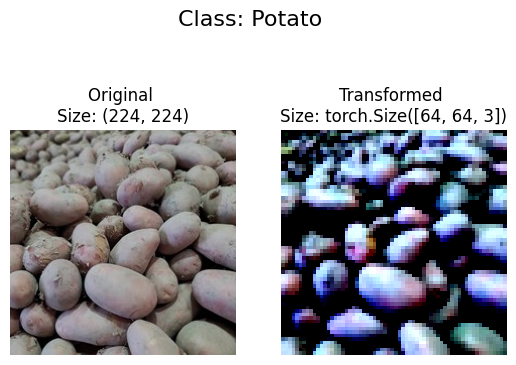

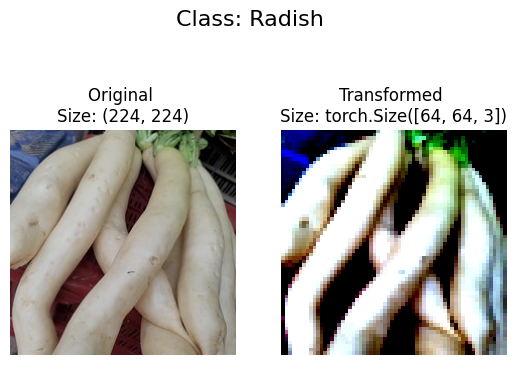

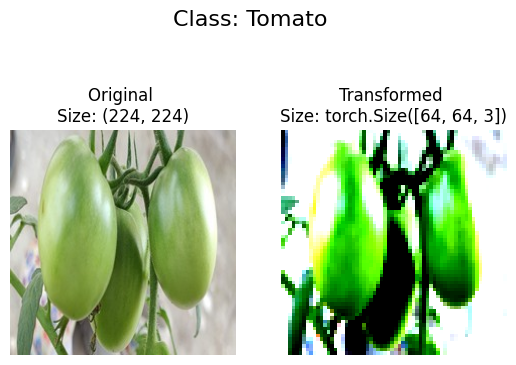

In [ ]:
image_path_list = list(image_path.glob("*/*/*.jpg"))
plot_transformed_images(image_path_list,
                        transform=data_transform,
                        n=3)

## **Model building**

We have 2 models:
 * model 0: TinyVGG - inspired by VGG16
 * Model 1: Efficient net implementation

However, for this notebook we will apply the model 1.

In [ ]:
# Model 0: TinyVGG model  # However, we are not using this model
class TinyVGG(nn.Module):
    """
    Model architecture copying TinyVGG from: # Inspired by VGG16 model
    https://poloclub.github.io/cnn-explainer/
    """
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int) -> None:
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=3, # how big is the square that's going over the image?
                      stride=1, # default
                      padding=1), # options = "valid" (no padding) or "same" (output has same shape as input) or int for specific number
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2) # default stride value is same as kernel_size
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            # Where did this in_features shape come from?
            # It's because each layer of our network compresses and changes the shape of our input data.
            nn.Linear(in_features=hidden_units*16*16,
                      out_features=output_shape)
        )

    def forward(self, x: torch.Tensor): # Inference dari model
        x = self.conv_block_1(x)
        x = self.conv_block_2(x)
        x = self.classifier(x)
        return x

torch.manual_seed(42)
model_0 = TinyVGG(input_shape=3,
                  hidden_units=10,
                  output_shape=len(train_data.classes)).to(device)
model_0

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2560, out_features=15, bias=True)
  )
)

In [ ]:
# Setting model (with Transfer learning)
class MyCustomModel(nn.Module):
    def __init__(self, num_classes: int) -> None:
        super().__init__()
        self.model = models.efficientnet_b1(weights="DEFAULT") # Efficientnet implementation
        in_features = self.model.classifier[1].in_features
        self.model.classifier = nn.Sequential(
            nn.Dropout(p=0.4, inplace=True),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x: torch.Tensor):
        x = self.model(x)
        return x

In [ ]:
# Defining model
torch.manual_seed(42)
model_1 = MyCustomModel(num_classes=len(train_data.classes)).to(device)
model_1

Downloading: "https://download.pytorch.org/models/efficientnet_b1-c27df63c.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b1-c27df63c.pth


100%|██████████| 30.1M/30.1M [00:00<00:00, 205MB/s]


MyCustomModel(
  (model): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
              (activation): SiLU(inplace=True)
              (scale_a

In [ ]:
# Sanity check and simulate prediction
# 1. Get a batch of images and labels from the DataLoader
img_batch, label_batch = next(iter(train_dataloader))

# 2. Get a single image from the batch and unsqueeze the image so its shape fits the model
img_single, label_single = img_batch[0].unsqueeze(dim=0), label_batch[0]
print(f"Single image shape: {img_single.shape}\n")

# 3. Perform a forward pass on a single image
model_1.eval()
with torch.inference_mode():
    pred = model_1(img_single.to(device))

# 4. Print out what's happening and convert model logits -> pred probs -> pred label
print(f"Output logits:\n{pred}\n")
print(f"Output prediction probabilities:\n{torch.softmax(pred, dim=1)}\n")
print(f"Output prediction label:\n{torch.argmax(torch.softmax(pred, dim=1), dim=1)}\n")
print(f"Actual label:\n{label_single}")

Single image shape: torch.Size([1, 3, 64, 64])

Output logits:
tensor([[ 0.1858, -0.0532,  0.0687,  0.1449, -0.0398,  0.0477,  0.0732,  0.0685,
          0.0498,  0.1065, -0.1120,  0.0339,  0.0720,  0.0292, -0.0998]],
       device='cuda:0')

Output prediction probabilities:
tensor([[0.0770, 0.0606, 0.0685, 0.0739, 0.0615, 0.0671, 0.0688, 0.0685, 0.0672,
         0.0711, 0.0572, 0.0662, 0.0687, 0.0658, 0.0579]], device='cuda:0')

Output prediction label:
tensor([0], device='cuda:0')

Actual label:
6


**Model training**

In [ ]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer):
    # Put model in train mode
    model.train()

    # Setup train loss and train accuracy values
    train_loss, train_acc = 0, 0

    # Loop through data loader data batches
    for batch, (X, y) in enumerate(dataloader):
        # Send data to target device
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate  and accumulate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

        # Calculate and accumulate accuracy metrics across all batches
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item()/len(y_pred)

    # Adjust metrics to get average loss and accuracy per batch
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc

In [ ]:
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module):
    # Put model in eval mode
    model.eval()

    # Setup test loss and test accuracy values
    test_loss, test_acc = 0, 0

    # Turn on inference context manager
    with torch.inference_mode():
        # Loop through DataLoader batches
        for batch, (X, y) in enumerate(dataloader):
            # Send data to target device
            X, y = X.to(device), y.to(device)

            # 1. Forward pass
            test_pred_logits = model(X)

            # 2. Calculate and accumulate loss
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            # Calculate and accumulate accuracy
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))

    # Adjust metrics to get average loss and accuracy per batch
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc

**Model evaluation**

In [ ]:
from tqdm.auto import tqdm

def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 10):

    best_acc = 0
    # 2. Create empty results dictionary
    results = {"train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    # 3. Loop through training and testing steps for a number of epochs
    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer)
        test_loss, test_acc = test_step(model=model,
            dataloader=test_dataloader,
            loss_fn=loss_fn)

        print(
            f"Epoch: {epoch+1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f}"
        )

        if test_acc > best_acc:
            best_acc = test_acc
            torch.save(model.state_dict(), "best.pt")
            print(f"saving model with test accuracy: {test_acc}")

        # 5. Update results dictionary

        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
        results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)

    # 6. Return the filled results at the end of the epochs
    return results

In [ ]:
# Set random seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set number of epochs
NUM_EPOCHS = 30

# Recreate an instance of TinyVGG
model_1.to(device)

# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss() # Multiclass case
optimizer = torch.optim.Adam(params=model_1.parameters(), lr=0.0001) # adam juga template

# Start the timer
from timeit import default_timer as timer
start_time = timer()

# Train model_0
model_0_results = train(model=model_1,
                        train_dataloader=train_dataloader,
                        test_dataloader=test_dataloader,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=NUM_EPOCHS)

# End the timer and print out how long it took
end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/30 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.9461 | train_acc: 0.5323 | test_loss: 0.6885 | test_acc: 0.8721
saving model with test accuracy: 0.8721168154761906
Epoch: 2 | train_loss: 0.3953 | train_acc: 0.9113 | test_loss: 0.1498 | test_acc: 0.9629
saving model with test accuracy: 0.9629371279761906
Epoch: 3 | train_loss: 0.1454 | train_acc: 0.9639 | test_loss: 0.0661 | test_acc: 0.9845
saving model with test accuracy: 0.9845145089285715
Epoch: 4 | train_loss: 0.0719 | train_acc: 0.9834 | test_loss: 0.0309 | test_acc: 0.9928
saving model with test accuracy: 0.9928385416666666
Epoch: 5 | train_loss: 0.0457 | train_acc: 0.9895 | test_loss: 0.0237 | test_acc: 0.9922
Epoch: 6 | train_loss: 0.0344 | train_acc: 0.9920 | test_loss: 0.0172 | test_acc: 0.9954
saving model with test accuracy: 0.9954427083333334
Epoch: 7 | train_loss: 0.0212 | train_acc: 0.9953 | test_loss: 0.0142 | test_acc: 0.9954
Epoch: 8 | train_loss: 0.0175 | train_acc: 0.9959 | test_loss: 0.0109 | test_acc: 0.9964
saving model with test accur

## **Conclusion**

This notebook showed how to classify vegetable images using a technique called transfer learning with an EfficientNet model. The model performed well on the test images (accuracy 99.8%), meaning it's good at telling different vegetables apart. This method is helpful because it uses a pre-trained model to get good results even when we don't have a lot of our own training pictures, which is often the case in real-world tasks.